# BM25 Keyword Search — The Foundation Every RAG System Needs

**Goal**: Build a production-grade keyword search layer over our paper corpus.

By the end of this notebook you will understand:
- Why keyword search comes *before* vectors in a professional RAG stack
- How BM25 actually scores documents — the math, not just the name
- OpenSearch Query DSL: `multi_match`, field boosting, filters, pagination
- The difference between a `query` clause and a `filter` clause in OpenSearch
- How to sync data from PostgreSQL into OpenSearch (the indexing problem)
- How to measure whether your search is actually working

---

## Why Keyword Search First?

Most RAG tutorials skip straight to embeddings. Production teams don't.

| Concern | BM25 | Vector Search |
|---------|------|---------------|
| Speed | ~5ms | ~50–200ms |
| Cost | Free (local) | Embedding API per query |
| Exact term matching | ✅ Perfect | ❌ Can miss exact matches |
| Paraphrase/synonym matching | ❌ Misses | ✅ Handles |
| Debuggability | ✅ Score is explainable | ❌ Black box |
| No GPU/API required | ✅ | Depends |

For technical domains like arXiv papers, **exact term matching matters enormously**. If a user searches "RLHF" or "FlashAttention", they want those exact tokens found — not something semantically similar.

The professional approach: **nail BM25 first, then add vectors on top**. A shaky retrieval foundation means shaky answers, no matter how good your LLM is.

---

## Section 1: BM25 — Understanding the Algorithm

BM25 is the scoring formula OpenSearch uses to rank results. Understanding it lets you tune it.

### The Formula

For a query term `q` in document `d`:

$$\text{score}(d, q) = IDF(q) \times \frac{TF(q,d) \cdot (k_1 + 1)}{TF(q,d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{avgdl}\right)}$$

Where:
- **TF** (Term Frequency): how often the term appears in the document
- **IDF** (Inverse Document Frequency): how rare the term is across all documents
- **|d|**: length of the document
- **avgdl**: average document length across the corpus
- **k1** (default 1.2): controls TF saturation — higher = more weight on repeated terms
- **b** (default 0.75): controls length normalization — 1.0 = full, 0.0 = none

Let's compute BM25 scores by hand to build intuition.

In [1]:
import math

def idf(n_docs: int, doc_freq: int) -> float:
    """
    BM25 IDF component.
    n_docs   = total number of documents in the corpus
    doc_freq = number of documents containing this term
    """
    return math.log(1 + (n_docs - doc_freq + 0.5) / (doc_freq + 0.5))

def bm25_score(
    tf: int,          # term frequency in this document
    doc_len: int,     # length of this document (in tokens)
    avg_dl: float,    # average document length in corpus
    idf_val: float,
    k1: float = 1.2,
    b: float = 0.75,
) -> float:
    numerator   = tf * (k1 + 1)
    denominator = tf + k1 * (1 - b + b * (doc_len / avg_dl))
    return idf_val * (numerator / denominator)


# Scenario: searching for "attention" across 3 papers
N_DOCS = 1000       # imagine 1000 papers in our corpus
DOC_FREQ = 200      # "attention" appears in 200 of them
AVG_DL = 800        # average paper is 800 tokens

idf_attention = idf(N_DOCS, DOC_FREQ)
print(f"IDF for 'attention' (appears in {DOC_FREQ}/{N_DOCS} docs): {idf_attention:.4f}")
print(f"→ Lower IDF = common term = less discriminative")
print()

# Compare scores for 3 hypothetical papers
papers = [
    {"name": "Short paper mentioning attention once",  "tf": 1,  "len": 200},
    {"name": "Long paper mentioning attention once",   "tf": 1,  "len": 2000},
    {"name": "Focused paper on attention (10 times)",  "tf": 10, "len": 800},
]

print(f"{'Paper':<45} {'Score':>8}")
print("-" * 55)
for p in papers:
    score = bm25_score(p["tf"], p["len"], AVG_DL, idf_attention)
    print(f"{p['name']:<45} {score:>8.4f}")

IDF for 'attention' (appears in 200/1000 docs): 1.6079
→ Lower IDF = common term = less discriminative

Paper                                            Score
-------------------------------------------------------
Short paper mentioning attention once           2.3197
Long paper mentioning attention once            0.9965
Focused paper on attention (10 times)           3.1585


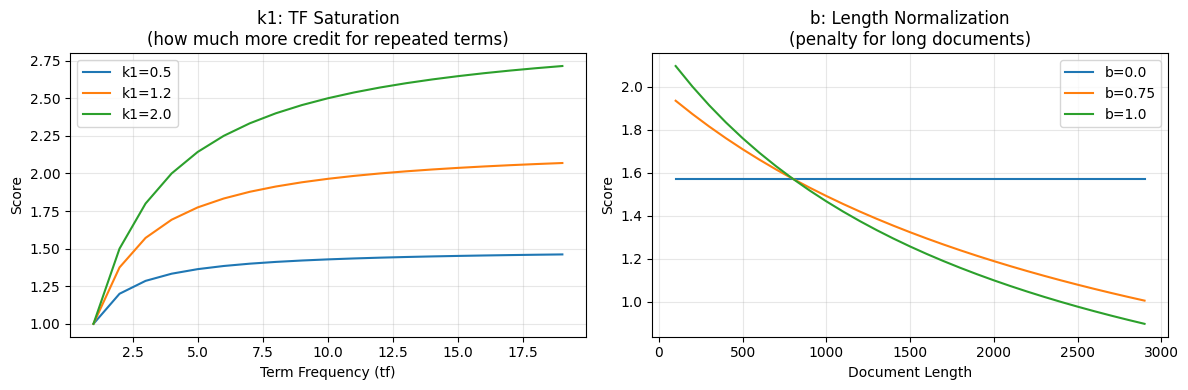


💡 k1=1.2: Good default. Avoids over-rewarding papers that spam a term.
💡 b=0.75: Papers are naturally long — apply moderate length penalty.
   For very long docs like academic papers, b=0.5-0.75 is often better.


In [3]:
# Now visualise how k1 and b affect scoring
import matplotlib.pyplot as plt
import numpy as np

tf_values = np.arange(1, 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Effect of k1 — TF saturation
for k1 in [0.5, 1.2, 2.0]:
    scores = [bm25_score(tf, 800, 800, 1.0, k1=k1, b=0.75) for tf in tf_values]
    ax1.plot(tf_values, scores, label=f"k1={k1}")
ax1.set_title("k1: TF Saturation\n(how much more credit for repeated terms)")
ax1.set_xlabel("Term Frequency (tf)")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(alpha=0.3)

# Effect of b — length normalization
doc_lengths = np.arange(100, 3000, 100)
for b in [0.0, 0.75, 1.0]:
    scores = [bm25_score(3, dl, 800, 1.0, k1=1.2, b=b) for dl in doc_lengths]
    ax2.plot(doc_lengths, scores, label=f"b={b}")
ax2.set_title("b: Length Normalization\n(penalty for long documents)")
ax2.set_xlabel("Document Length")
ax2.set_ylabel("Score")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("💡 k1=1.2: Good default. Avoids over-rewarding papers that spam a term.")
print("💡 b=0.75: Papers are naturally long — apply moderate length penalty.")
print("   For very long docs like academic papers, b=0.5-0.75 is often better.")

### 💡 Key insight: BM25 vs TF-IDF

TF-IDF is the predecessor. BM25 fixes two problems:

1. **TF saturation**: In TF-IDF, a document mentioning "attention" 100 times scores 100× better than one mentioning it once. That's unrealistic — the 100th mention adds almost no information. BM25's k1 parameter caps this saturation.

2. **Length normalization**: Long documents naturally contain more term occurrences. BM25's b parameter normalizes for document length — a 10-page paper shouldn't automatically beat a focused 1-page abstract.

This is why OpenSearch defaults to BM25, not TF-IDF.

---

## Section 2: OpenSearch Index Configuration

### Concept: Index = Schema + Analyzer + Settings

An OpenSearch index is more than just storage. It defines:
- **Mappings**: how each field is stored and indexed (like SQL schema)
- **Analyzers**: how text is broken into tokens before indexing
- **Settings**: shards, replicas, BM25 k1/b parameters

Getting mappings right at index creation time matters — changing them later requires a full reindex.

In [4]:
# Our production index configuration — every decision is deliberate

PAPERS_INDEX_CONFIG = {
    "settings": {
        "number_of_shards": 1,
        "number_of_replicas": 0,

        # BM25 tuning — applied at index level
        # k1=1.2: default, good for mixed-length docs
        # b=0.75: moderate length normalization
        # Academic papers are naturally long — we want moderate penalization
        "similarity": {
            "bm25_similarity": {
                "type": "BM25",
                "k1": 1.2,
                "b": 0.75,
                "discount_overlaps": True,  # ignore stop words in length calc
            }
        },

        "analysis": {
            "analyzer": {
                # Custom academic text analyzer
                # Handles: case, stop words, and stemming
                # Conservative: snowball (not aggressive) preserves technical terms
                "paper_analyzer": {
                    "type": "custom",
                    "tokenizer": "standard",        # word boundary splitting
                    "filter": [
                        "lowercase",                # "Transformer" → "transformer"
                        "stop",                     # remove "the", "is", "at"
                        "snowball",                 # "running" → "run"
                    ]
                }
            }
        },
    },

    "mappings": {
        "properties": {
            # ── keyword fields: exact match, no analysis
            # Use for: filters, aggregations, sorting
            # DO NOT use 'text' for these — you need exact strings
            "arxiv_id":    {"type": "keyword"},
            "authors":     {"type": "keyword"},
            "categories":  {"type": "keyword"},

            # ── text fields: full-text search with BM25
            # 'fields.keyword' sub-field allows exact sort without re-indexing
            "title": {
                "type": "text",
                "analyzer": "paper_analyzer",
                "similarity": "bm25_similarity",
                "fields": {
                    "keyword": {"type": "keyword", "ignore_above": 512}
                }
            },
            "abstract": {
                "type": "text",
                "analyzer": "paper_analyzer",
                "similarity": "bm25_similarity",
            },
            "full_text": {
                "type": "text",
                "analyzer": "paper_analyzer",
                "similarity": "bm25_similarity",
                # index_options=offsets: enables fast highlighting
                "index_options": "offsets",
            },

            # ── date field: range queries, recency sorting
            "published_at": {"type": "date"},

            # ── boolean: quick filter for papers with parsed content
            "pdf_parsed": {"type": "boolean"},
        }
    },
}

import json
print("Index config (settings excerpt):")
print(json.dumps(PAPERS_INDEX_CONFIG["settings"]["similarity"], indent=2))
print()
print("Mappings field types:")
for field, config in PAPERS_INDEX_CONFIG["mappings"]["properties"].items():
    print(f"  {field:<15} → {config['type']}")

Index config (settings excerpt):
{
  "bm25_similarity": {
    "type": "BM25",
    "k1": 1.2,
    "b": 0.75,
    "discount_overlaps": true
  }
}

Mappings field types:
  arxiv_id        → keyword
  authors         → keyword
  categories      → keyword
  title           → text
  abstract        → text
  full_text       → text
  published_at    → date
  pdf_parsed      → boolean


### 💡 Key insight: `keyword` vs `text` — the most important mapping decision

```python
# If 'categories' is mapped as text:
filter: {"term": {"categories": "cs.AI"}}  # FAILS — tokenizer split "cs.AI" into ["cs", "ai"]

# If 'categories' is mapped as keyword:
filter: {"term": {"categories": "cs.AI"}}  # WORKS — stored as exact string
```

Rule of thumb:
- If you search **inside** it (words) → `text`
- If you match **against** it (whole value) → `keyword`

### 💡 Key insight: `index_options: offsets` on `full_text`

This stores the character positions of each token. Used for **highlighting** — returning the exact sentence from the paper that matched the query. Costs a bit more disk space but makes search results dramatically more useful.

---

## Section 3: Query DSL — Building Search Queries

### Concept: The Bool Query — the backbone of all real searches

Every production search is a `bool` query with clauses:

| Clause | Behaviour | Affects Score? |
|--------|-----------|----------------|
| `must` | Document MUST match — like SQL `AND` | ✅ Yes |
| `should` | Document SHOULD match — boosts score | ✅ Yes |
| `filter` | Document MUST match — binary include/exclude | ❌ No |
| `must_not` | Document MUST NOT match | ❌ No |

The critical distinction: **`filter` does not affect relevance scores** and is cached by OpenSearch. This makes category/date filtering fast.

In [5]:
from datetime import date
from typing import Optional

def build_bm25_query(
    query_text: str,
    categories: Optional[list[str]] = None,
    date_from: Optional[date] = None,
    date_to: Optional[date] = None,
    from_: int = 0,
    size: int = 10,
    include_full_text: bool = True,
) -> dict:
    """
    Build a production BM25 query with optional filters.

    Field boosts:
      title^3   — a title match is 3× more significant than a body match
      abstract^2 — abstract is denser signal than full text
      full_text^1 — baseline

    'best_fields' type: takes the score from the single best-matching field.
    Good for: queries that are likely about a specific aspect of the paper.
    Alternative 'most_fields': sums scores across all fields (can overcount).
    """

    # Fields to search — only include full_text if paper has been parsed
    search_fields = ["title^3", "abstract^2"]
    if include_full_text:
        search_fields.append("full_text^1")

    # The multi_match is the 'must' clause — drives relevance scoring
    multi_match = {
        "multi_match": {
            "query": query_text,
            "fields": search_fields,
            "type": "best_fields",
            "operator": "or",        # any word matches
            "fuzziness": "AUTO",     # handles typos: "attentoin" → "attention"
            "tie_breaker": 0.3,      # partial credit for secondary field matches
        }
    }

    # Filter clauses: binary include/exclude, don't affect score, get cached
    filters = []

    if categories:
        # 'terms' matches any value in the list
        filters.append({"terms": {"categories": categories}})

    if date_from or date_to:
        date_range = {}
        if date_from:
            date_range["gte"] = date_from.isoformat()
        if date_to:
            date_range["lte"] = date_to.isoformat()
        filters.append({"range": {"published_at": date_range}})

    # Assemble the full bool query
    bool_query = {"must": [multi_match]}
    if filters:
        bool_query["filter"] = filters

    return {
        "from": from_,
        "size": size,
        "query": {"bool": bool_query},

        # Highlighting: return matching snippets from the document
        "highlight": {
            "fields": {
                "title":    {"number_of_fragments": 0},     # return full title
                "abstract": {"number_of_fragments": 2, "fragment_size": 200},
            },
            "pre_tags": ["<mark>"],
            "post_tags": ["</mark>"],
        },

        # Only return fields we need — don't send full_text back (it's large)
        "_source": {
            "excludes": ["full_text"]
        },
    }


# Example 1: Plain search
q1 = build_bm25_query("transformer attention mechanism")
print("Query 1 — plain search:")
print(json.dumps(q1["query"], indent=2))

print()

# Example 2: With category filter and date range
q2 = build_bm25_query(
    "retrieval augmented generation",
    categories=["cs.AI", "cs.CL"],
    date_from=date(2024, 1, 1),
)
print("Query 2 — with category filter + date range:")
print(json.dumps(q2["query"], indent=2))

Query 1 — plain search:
{
  "bool": {
    "must": [
      {
        "multi_match": {
          "query": "transformer attention mechanism",
          "fields": [
            "title^3",
            "abstract^2",
            "full_text^1"
          ],
          "type": "best_fields",
          "operator": "or",
          "fuzziness": "AUTO",
          "tie_breaker": 0.3
        }
      }
    ]
  }
}

Query 2 — with category filter + date range:
{
  "bool": {
    "must": [
      {
        "multi_match": {
          "query": "retrieval augmented generation",
          "fields": [
            "title^3",
            "abstract^2",
            "full_text^1"
          ],
          "type": "best_fields",
          "operator": "or",
          "fuzziness": "AUTO",
          "tie_breaker": 0.3
        }
      }
    ],
    "filter": [
      {
        "terms": {
          "categories": [
            "cs.AI",
            "cs.CL"
          ]
        }
      },
      {
        "range": {
          "publi

### 💡 Key insight: `fuzziness: AUTO`

Without fuzziness, a user typing "attentoin" gets zero results. With `AUTO`:
- Words 1–2 chars: exact match only
- Words 3–5 chars: 1 edit distance allowed
- Words 6+ chars: 2 edit distances allowed

This handles typos and minor spelling variations automatically, which matters a lot for technical terms.

### 💡 Key insight: Why filter clauses are faster than must

OpenSearch caches filter results in the **filter cache** (heap memory). The second time you filter `categories: cs.AI`, OpenSearch returns the cached bitset instantly — no re-scoring. Must clauses are not cached because they affect scores which depend on query context.

In [6]:
# Let's also look at a phrase search — useful for exact multi-word terms
def build_phrase_query(phrase: str, field: str = "abstract") -> dict:
    """
    Match an exact phrase in order.
    'match_phrase' requires words to appear consecutively.
    e.g. 'large language model' won't match 'model is a language'
    """
    return {
        "query": {
            "match_phrase": {
                field: {
                    "query": phrase,
                    "slop": 1,  # allow 1 word between phrase terms
                }
            }
        }
    }

def build_combined_query(text_query: str, boost_phrase: Optional[str] = None) -> dict:
    """
    Combine multi_match (recall) + match_phrase (precision boost).
    Papers containing the phrase as-written rank higher than ones with scattered words.
    """
    should_clauses = []
    if boost_phrase:
        should_clauses.append({
            "match_phrase": {
                "abstract": {"query": boost_phrase, "boost": 2.0}
            }
        })

    query = {
        "query": {
            "bool": {
                "must": [{"multi_match": {
                    "query": text_query,
                    "fields": ["title^3", "abstract^2", "full_text"],
                    "type": "best_fields",
                }}],
                "should": should_clauses,
            }
        },
        "size": 10,
    }
    return query

print("Phrase query (exact order required):")
print(json.dumps(build_phrase_query("large language model"), indent=2))

Phrase query (exact order required):
{
  "query": {
    "match_phrase": {
      "abstract": {
        "query": "large language model",
        "slop": 1
      }
    }
  }
}


---

## Section 4: Running Real Searches

Now let's run actual queries against your running OpenSearch instance.

In [7]:
from opensearchpy import OpenSearch

OPENSEARCH_CONFIG = {"host": "localhost", "port": 9200}
INDEX = "papers"

client = OpenSearch(
    hosts=[OPENSEARCH_CONFIG],
    http_compress=True,
    use_ssl=False,
    verify_certs=False,
)

# Check how many papers we have indexed
try:
    stats = client.indices.stats(index=INDEX)
    count = stats["_all"]["primaries"]["docs"]["count"]
    print(f"✅ OpenSearch connected")
    print(f"   Papers indexed: {count}")
    
    if count == 0:
        print()
        print("⚠️  No papers indexed yet — run Section 5 (indexing) first,")
        print("   then come back to run searches.")
except Exception as e:
    print(f"❌ {e}")

✅ OpenSearch connected
   Papers indexed: 1


In [8]:
def search_papers(query_text: str, categories=None, size=5) -> dict:
    """Run a BM25 search and return formatted results."""
    query = build_bm25_query(query_text, categories=categories, size=size)
    response = client.search(index=INDEX, body=query)

    hits = response["hits"]["hits"]
    total = response["hits"]["total"]["value"]
    took_ms = response["took"]

    print(f"Query: '{query_text}'")
    print(f"Found: {total} results in {took_ms}ms")
    print()

    for i, hit in enumerate(hits, 1):
        src = hit["_source"]
        highlights = hit.get("highlight", {})

        print(f"{i}. [{hit['_score']:.3f}] {src.get('title', 'No title')}")
        print(f"   arXiv: {src.get('arxiv_id')} | {src.get('published_at', '')[:10]}")
        print(f"   Categories: {src.get('categories', [])}")

        # Show highlighted abstract snippet if available
        if "abstract" in highlights:
            snippet = highlights["abstract"][0]
            # Clean HTML tags for notebook display
            snippet_clean = snippet.replace("<mark>", "**").replace("</mark>", "**")
            print(f"   Snippet: ...{snippet_clean}...")
        print()

    return response


# Run some searches — results depend on what papers you've ingested
r1 = search_papers("transformer attention mechanism", size=3)

Query: 'transformer attention mechanism'
Found: 1 results in 133ms

1. [0.863] Attention Is All You Need (Test Paper)
   arXiv: 2301.00001 | 2017-06-12
   Categories: ['cs.LG', 'cs.CL']



In [9]:
# Search with category filter
r2 = search_papers(
    "retrieval augmented generation",
    categories=["cs.AI", "cs.CL"],
    size=3
)

Query: 'retrieval augmented generation'
Found: 0 results in 21ms



In [12]:
# Inspect the raw score explanation — understand why a result ranked where it did
def explain_score(arxiv_id: str, query_text: str):
    """Ask OpenSearch to explain how it scored a specific document."""
    query = build_bm25_query(query_text)
    response = client.explain(
        index=INDEX,
        id=arxiv_id,
        body={"query": query["query"]}
    )

    if response["matched"]:
        exp = response["explanation"]
        print(f"Score explanation for '{arxiv_id}' matching '{query_text}':")
        print(f"  Total score: {exp['value']:.4f}")
        print(f"  Description: {exp['description'][:120]}")
        if "details" in exp:
            for detail in exp["details"][:3]:
                print(f"    - {detail['value']:.4f}: {detail['description'][:100]}")
    else:
        print(f"Document {arxiv_id} did not match query '{query_text}'")

explain_score("2301.00001", "attention mechanism")


Score explanation for '2301.00001' matching 'attention mechanism':
  Total score: 0.8630
  Description: max plus 0.3 times others of:
    - 0.8630: weight(title:attent in 0) [PerFieldSimilarity], result of:


---

## Section 5: Indexing — Syncing PostgreSQL → OpenSearch

### Concept: The sync problem

PostgreSQL is the source of truth. OpenSearch holds a search-optimised projection. These two must stay in sync.

Two strategies:
1. **Write-through**: index into OpenSearch at the same time as PostgreSQL write (in `metadata_fetcher.py`)
2. **Batch sync**: read from PostgreSQL, push to OpenSearch in bulk (via Airflow)

We use both: write-through for new papers, batch sync as a safety net.

In [13]:
import psycopg2
from psycopg2.extras import RealDictCursor

DB_CONFIG = {
    "host": "localhost", "port": 5432,
    "dbname": "ragdb", "user": "postgres", "password": "postgres",
    "cursor_factory": RealDictCursor,
}

# Fetch papers from PostgreSQL ready for indexing
FETCH_FOR_INDEX_SQL = """
SELECT
    arxiv_id, title, abstract, authors, categories,
    published_at, pdf_parsed, full_text
FROM papers
ORDER BY created_at DESC
LIMIT %(limit)s OFFSET %(offset)s;
"""

def fetch_papers_for_indexing(limit: int = 100, offset: int = 0) -> list:
    conn = psycopg2.connect(**DB_CONFIG)
    cursor = conn.cursor()
    cursor.execute(FETCH_FOR_INDEX_SQL, {"limit": limit, "offset": offset})
    rows = cursor.fetchall()
    conn.close()
    return [dict(r) for r in rows]


def prepare_for_index(paper: dict) -> dict:
    """
    Transform a PostgreSQL row into an OpenSearch document.

    Key decisions:
    - published_at: convert datetime to ISO string
    - full_text: include only if pdf_parsed (avoids indexing empty/None)
    - Exclude DB-specific fields (id, created_at, updated_at)
    """
    doc = {
        "arxiv_id":    paper["arxiv_id"],
        "title":       paper["title"],
        "abstract":    paper["abstract"] or "",
        "authors":     paper["authors"] or [],
        "categories":  paper["categories"] or [],
        "published_at": paper["published_at"].isoformat() if paper["published_at"] else None,
        "pdf_parsed":  paper["pdf_parsed"] or False,
    }
    # Only include full_text if it exists — avoids large None values
    if paper["pdf_parsed"] and paper.get("full_text"):
        doc["full_text"] = paper["full_text"]
    return doc


papers = fetch_papers_for_indexing(limit=5)
print(f"Fetched {len(papers)} papers from PostgreSQL")
if papers:
    sample = prepare_for_index(papers[0])
    print(f"\nSample document for indexing:")
    for k, v in sample.items():
        val_str = str(v)[:60] if v else "None"
        print(f"  {k:<15} {val_str}")

Fetched 4 papers from PostgreSQL

Sample document for indexing:
  arxiv_id        2604.08545
  title           Act Wisely: Cultivating Meta-Cognitive Tool Use in Agentic M
  abstract        The advent of agentic multimodal models has empowered system
  authors         ['Shilin Yan', 'Jintao Tong', 'Hongwei Xue', 'Xiaojun Tang',
  categories      ['cs.CV', 'cs.AI']
  published_at    2026-04-09T17:59:57
  pdf_parsed      True
  full_text       [Mock content for 2604.08545]


In [ ]:
# Bulk indexing — vastly faster than one document at a time
from opensearchpy.helpers import bulk

def bulk_index_papers(papers_from_db: list) -> dict:
    """
    Index a batch of papers using the OpenSearch bulk API.

    Bulk API vs individual index:
      100 papers × single index:  ~100 HTTP requests, ~2–5s
      100 papers × bulk:           1 HTTP request,   ~50ms

    We use arxiv_id as the document _id so re-indexing is idempotent.
    """
    actions = []
    for paper in papers_from_db:
        doc = prepare_for_index(paper)
        actions.append({
            "_op_type": "index",   # 'index' = upsert (insert or overwrite)
            "_index":   INDEX,
            "_id":      paper["arxiv_id"],  # stable ID = idempotent re-runs
            "_source":  doc,
        })

    if not actions:
        return {"indexed": 0, "errors": 0}

    success, errors = bulk(client, actions, raise_on_error=False, stats_only=False)
    return {"indexed": success, "errors": len(errors) if isinstance(errors, list) else errors}


# Index the papers we fetched
if papers:
    result = bulk_index_papers(papers)
    print(f"Bulk index result: {result}")

    # Refresh so results are immediately searchable (dev only — expensive!)
    client.indices.refresh(index=INDEX)
    
    new_count = client.count(index=INDEX)["count"]
    print(f"Total documents in index: {new_count}")
else:
    print("No papers to index — ingest some papers first via the Airflow DAG")

### 💡 Key insight: `_op_type: index` vs `create`

- `create`: fail if document already exists
- `index`: overwrite if exists (upsert)

We use `index` so the Airflow sync task is idempotent. Running it twice won't create duplicates.

### 💡 Key insight: `client.indices.refresh()` — dev vs production

By default, OpenSearch refreshes its index every 1 second, making new documents searchable. Calling `refresh()` explicitly forces an immediate refresh. This is expensive (blocks indexing) — only do this in notebooks/tests. In production, let the 1-second auto-refresh handle it.

---

## Section 6: Search Analytics — Measuring What You Built

You can't improve what you don't measure. Basic search analytics to include.

In [14]:
def get_index_stats() -> dict:
    """Comprehensive index health and content statistics."""
    try:
        stats = client.indices.stats(index=INDEX)
        count_resp = client.count(index=INDEX)
        
        primaries = stats["_all"]["primaries"]
        store_bytes = primaries["store"]["size_in_bytes"]
        
        # Category breakdown — how many papers per category?
        agg_resp = client.search(index=INDEX, body={
            "size": 0,  # don't return documents, just aggregations
            "aggs": {
                "by_category": {
                    "terms": {"field": "categories", "size": 10}
                },
                "pdf_parsed_count": {
                    "filter": {"term": {"pdf_parsed": True}}
                }
            }
        })
        
        categories = {
            b["key"]: b["doc_count"]
            for b in agg_resp["aggregations"]["by_category"]["buckets"]
        }
        parsed_count = agg_resp["aggregations"]["pdf_parsed_count"]["doc_count"]
        total = count_resp["count"]
        
        return {
            "total_documents": total,
            "pdf_parsed":      parsed_count,
            "pdf_pending":     total - parsed_count,
            "index_size_mb":   round(store_bytes / (1024 * 1024), 2),
            "search_queries":  primaries.get("search", {}).get("query_total", 0),
            "avg_query_ms":    round(primaries.get("search", {}).get("query_time_in_millis", 0) /
                                     max(primaries.get("search", {}).get("query_total", 1), 1), 2),
            "categories":      categories,
        }
    except Exception as e:
        return {"error": str(e)}


stats = get_index_stats()
print("=" * 50)
print("SEARCH INDEX ANALYTICS")
print("=" * 50)
for k, v in stats.items():
    if k != "categories":
        print(f"  {k:<25} {v}")

if "categories" in stats and stats["categories"]:
    print("\n  Category breakdown:")
    for cat, count in sorted(stats["categories"].items(), key=lambda x: -x[1]):
        bar = "█" * min(count, 30)
        print(f"    {cat:<12} {bar} {count}")

SEARCH INDEX ANALYTICS
  total_documents           1
  pdf_parsed                0
  pdf_pending               1
  index_size_mb             0.01
  search_queries            3
  avg_query_ms              2.67

  Category breakdown:
    cs.CL        █ 1
    cs.LG        █ 1


In [15]:
# Relevance sanity check — run a test suite of queries
# This is the simplest form of search evaluation

TEST_QUERIES = [
    {"query": "transformer self-attention",       "expected_category": "cs.LG"},
    {"query": "retrieval augmented generation",   "expected_category": "cs.CL"},
    {"query": "reinforcement learning reward",    "expected_category": "cs.AI"},
    {"query": "image classification convolutional", "expected_category": "cs.CV"},
]

print(f"{'Query':<40} {'Top Result':<45} {'Correct Cat?'}")
print("-" * 100)

for test in TEST_QUERIES:
    try:
        q = build_bm25_query(test["query"], size=1)
        resp = client.search(index=INDEX, body=q)
        hits = resp["hits"]["hits"]
        
        if hits:
            top = hits[0]["_source"]
            cats = top.get("categories", [])
            correct = test["expected_category"] in cats
            icon = "✅" if correct else "⚠️ "
            title_short = top.get("title", "")[:40]
            print(f"{test['query']:<40} {title_short:<45} {icon}")
        else:
            print(f"{test['query']:<40} {'(no results)':<45} —")
    except Exception as e:
        print(f"{test['query']:<40} ERROR: {e}")

Query                                    Top Result                                    Correct Cat?
----------------------------------------------------------------------------------------------------
transformer self-attention               Attention Is All You Need (Test Paper)        ✅
retrieval augmented generation           (no results)                                  —
reinforcement learning reward            (no results)                                  —
image classification convolutional       Attention Is All You Need (Test Paper)        ⚠️ 


---

## Summary — What You Built

```
✅ BM25 math understood — TF, IDF, k1, b parameters
✅ Index config as code — mappings, custom analyzer, BM25 similarity
✅ Query DSL mastered — bool/must/filter, multi_match, field boosting
✅ Filters vs queries — binary include/exclude vs relevance-affecting
✅ Fuzziness for typo tolerance
✅ Highlighting — returning matching snippets to the user
✅ Bulk indexing — PostgreSQL → OpenSearch in one HTTP request
✅ Idempotent re-indexing — arxiv_id as stable _id
✅ Search analytics — index stats, category breakdown, query performance
✅ Relevance testing — sanity-check your search with a query test suite
```

### Concepts mastered:
- **BM25 k1 and b**: not just defaults — you now know what changing them does
- **`keyword` vs `text`**: the most common OpenSearch mistake, now understood
- **`filter` cache**: why date/category filters are faster than must clauses
- **`best_fields` vs `most_fields`**: which query type to use when
- **Bulk API**: 100× faster than individual document indexing
- **`_op_type: index`**: upsert semantics for idempotent pipelines
- **`explain` API**: debugging why a document scored what it did

---
*Branch: `feature/keyword-search`*